Found 1371 files belonging to 9 classes.
Found 299 files belonging to 9 classes.
Found 296 files belonging to 9 classes.

Classes Found:
['AMD_Mild', 'AMD_Moderate', 'AMD_Severe', 'DME_Normal', 'DME_Severe', 'ERM_Normal', 'NO_Normal', 'RVO_Other', 'RVO_Severe']

Number of Classes : 9
Class Weights: {0: 0.8856589147286822, 1: 0.9288617886178862, 2: 0.2907124681933842, 3: 1.6205673758865249, 4: 12.694444444444445, 5: 1.4934640522875817, 6: 0.6861861861861862, 7: 2.3435897435897437, 8: 9.520833333333334}
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 sequential_4 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
         

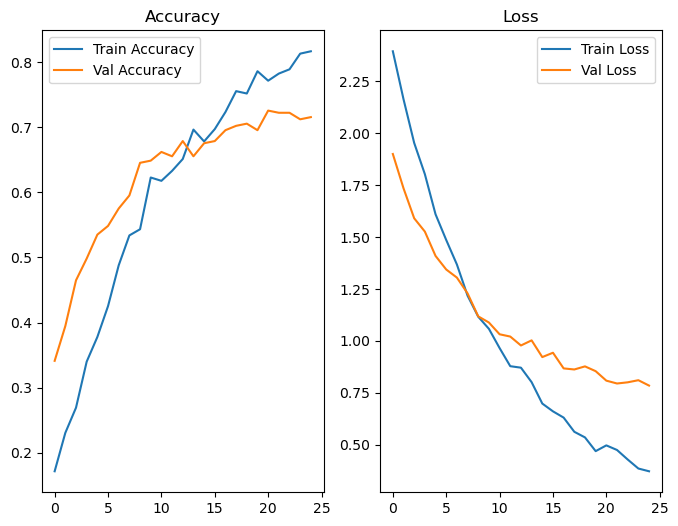

In [2]:
# ================= IMPORT LIBRARIES =================
import numpy as np
import seaborn as sns
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


# ================= CONSTANTS =================
IMAGE_SIZE = 224
BATCH_SIZE = 16
CHANNELS = 3
EPOCHS = 25
SEED = 123

# ================= GPU CONFIG =================
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# ================= DATASET PATHS =================

TRAIN_DIR = r"C:\Users\ALFA\Codes\Optical_Coherence_Tomography\Training\ORIGINAL_OCTDL_DATA_REDUCED\Relabelled_OCT\train"

VAL_DIR = r"C:\Users\ALFA\Codes\Optical_Coherence_Tomography\Training\ORIGINAL_OCTDL_DATA_REDUCED\Relabelled_OCT\validation"

TEST_DIR = r"C:\Users\ALFA\Codes\Optical_Coherence_Tomography\Training\ORIGINAL_OCTDL_DATA_REDUCED\Relabelled_OCT\test"


# ================= LOAD TRAIN DATA =================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


# ================= LOAD VALIDATION DATA =================

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ================= LOAD TEST DATA =================

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ================= CLASS INFORMATION =================

class_names = train_ds.class_names

NUM_CLASSES = len(class_names)

print("\nClasses Found:")
print(class_names)

print(f"\nNumber of Classes : {NUM_CLASSES}")

# ================= COMPUTE CLASS WEIGHTS =================
y_train = []

for images, labels in train_ds:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# ================= PERFORMANCE OPTIMIZATION =================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .cache()
    .prefetch(AUTOTUNE)
)

# ================= DATA AUGMENTATION =================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ================= PREPROCESSING =================
preprocess = tf.keras.Sequential([
    layers.Lambda(preprocess_input)
])

# ================= LOAD PRETRAINED MODEL =================
base_model = ResNet50(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS),
    include_top=False,
    weights='imagenet'
)

# ================= FREEZE MOST LAYERS =================
base_model.trainable = True

for layer in base_model.layers[:-30]:   # stronger regularization
    layer.trainable = False

# ================= BUILD MODEL =================
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    data_augmentation,
    preprocess,
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    layers.Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# ================= COMPILE =================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet50.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger("training_log.csv")
]

# ================= TRAIN =================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,   # ✅ IMPORTANT
    callbacks=callbacks
)

# ================= SAVE BEST MODEL =================
model.save("oct_resnet50.keras")

# ================= EVALUATE =================
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")

# ================= PLOT TRAINING =================
plt.figure(figsize=(8,6))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [3]:
# ================= EVALUATE =================
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")

19/19 [==============================] - 1s 54ms/step - loss: 0.7110 - accuracy: 0.7331

Test Accuracy: 0.7331


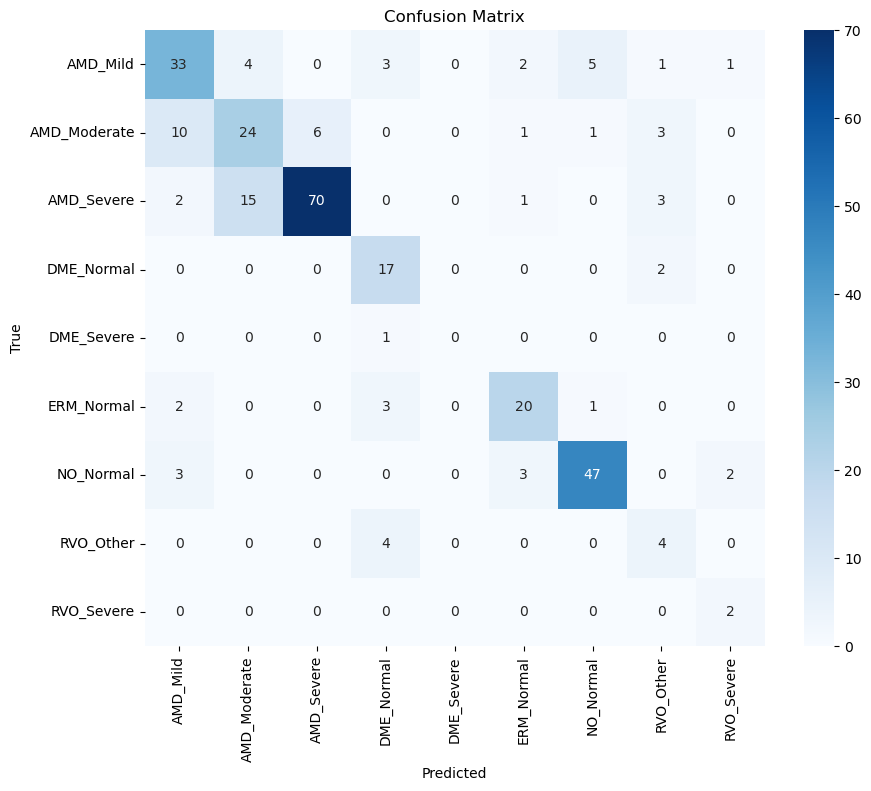

              precision    recall  f1-score   support

    AMD_Mild       0.66      0.67      0.67        49
AMD_Moderate       0.56      0.53      0.55        45
  AMD_Severe       0.92      0.77      0.84        91
  DME_Normal       0.61      0.89      0.72        19
  DME_Severe       0.00      0.00      0.00         1
  ERM_Normal       0.74      0.77      0.75        26
   NO_Normal       0.87      0.85      0.86        55
   RVO_Other       0.31      0.50      0.38         8
  RVO_Severe       0.40      1.00      0.57         2

    accuracy                           0.73       296
   macro avg       0.56      0.67      0.59       296
weighted avg       0.75      0.73      0.74       296



C:\Users\ALFA\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ALFA\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ALFA\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [4]:
# ================= PREDICTIONS =================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ================= CONFUSION MATRIX =================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()


# ================= CLASSIFICATION REPORT =================

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))